In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import io
import zipfile
import urllib.request
import statsmodels.api as sm
import os

In [3]:
# loading data
RAW_DIR = Path("../data/raw")

industry_returns = pd.read_parquet(RAW_DIR / "industry_returns.parquet")
baseline = pd.read_parquet(RAW_DIR / "baseline_momentum.parquet")
residual = pd.read_parquet(RAW_DIR / "residual_momentum.parquet")

### Forming a portfolio for one month by hand

Strategy: top 5 industries are long portfolio, bottom 5 industries are short portfolio, return is avg(long return) - avg(short return)

In [4]:
# identifying signals
date = "1990-01-31"

signals = baseline.loc[date]
signals = signals.dropna()
signals = signals.sort_values(ascending=False)

long_industries = signals.head(5).index.tolist()
short_industries = signals.tail(5).index.tolist()

print(f"Long (top 5): {long_industries}")
print(f"Short (bottom 5): {short_industries}")

Long (top 5): ['Fun', 'Smoke', 'Toys', 'Beer', 'Hlth']
Short (bottom 5): ['Autos', 'Soda', 'RlEst', 'Ships', 'Hardw']


In [5]:
# computing returns on next month
next_month = pd.Timestamp(date) + pd.offsets.MonthEnd(1)
print(f"Holding period return month: {next_month.date()}")

next_returns = industry_returns.loc[next_month]
long_return = next_returns[long_industries].mean()
short_return = next_returns[short_industries].mean()
strategy_return = long_return - short_return

print(f"Average return of long portfolio: {long_return:.2f}%")
print(f"Average return of short portfolio: {short_return:.2f}%")
print(f"Strategy return (long - short): {strategy_return:.2f}%")

Holding period return month: 1990-02-28
Average return of long portfolio: -0.30%
Average return of short portfolio: 0.18%
Strategy return (long - short): -0.48%


### Loop through all months (Baseline Only)

In [6]:
strategy_returns = {}

for date in baseline.index:
    # get signals
    signals = baseline.loc[date]
    signals = signals.dropna()
    signals = signals.sort_values(ascending=False)
    if len(signals) < 10: # need at least 10 industries
        continue

    long_industries = signals.head(5).index.tolist()
    short_industries = signals.tail(5).index.tolist()

    # compute returns on next month
    next_month = pd.Timestamp(date) + pd.offsets.MonthEnd(1)
    if next_month not in industry_returns.index:
        continue

    next_returns = industry_returns.loc[next_month]
    strategy_return = next_returns[long_industries].mean() - next_returns[short_industries].mean()
    strategy_returns[next_month] = strategy_return

# convert to series
strategy_returns = pd.Series(strategy_returns).sort_index()
strategy_returns.name = "baseline_momentum"

print(f"Date range: {strategy_returns.index.min().date()} to {strategy_returns.index.max().date()}")
print("Summary statistics (monthly returns, in percent):")
print(strategy_returns.describe())

Date range: 1964-08-31 to 2026-04-30
Summary statistics (monthly returns, in percent):
count    741.000000
mean       0.911622
std        6.055393
min      -38.686000
25%       -2.476000
50%        1.168000
75%        4.412000
max       20.914000
Name: baseline_momentum, dtype: float64


In [7]:
# annualized numbers
ann_mean = strategy_returns.mean() * 12
ann_std = strategy_returns.std() * np.sqrt(12)
ann_sharpe = ann_mean / ann_std

print(f"Annualized return: {ann_mean:.2f}%")
print(f"Annualized volatility: {ann_std:.2f}%")
print(f"Annualized Sharpe: {ann_sharpe:.2f}")

Annualized return: 10.94%
Annualized volatility: 20.98%
Annualized Sharpe: 0.52


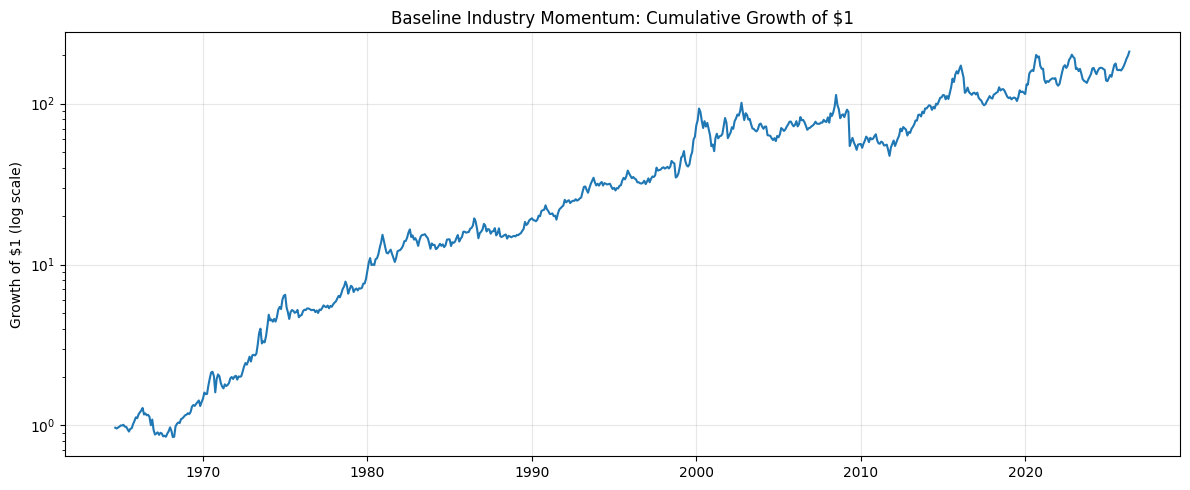

In [8]:
# plot cumulative returns
cum = (1 + strategy_returns / 100).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum.index, cum.values)
ax.set_yscale("log")  # log scale because cumulative returns grow exponentially over decades
ax.set_title("Baseline Industry Momentum: Cumulative Growth of $1")
ax.set_ylabel("Growth of $1 (log scale)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Convert this loop into a function that we can use on a given df

In [9]:
def build_strategy_returns(signal_df, returns_df, n_long=5, n_short=5):
    strategy = {}

    for date in signal_df.index:
        # get signals
        signals = signal_df.loc[date]
        signals = signals.dropna()
        signals = signals.sort_values(ascending=False)
        if len(signals) < 10: # need at least 10 industries
            continue
    
        long_industries = signals.head(n_long).index.tolist()
        short_industries = signals.tail(n_short).index.tolist()
    
        # compute returns on next month
        next_month = pd.Timestamp(date) + pd.offsets.MonthEnd(1)
        if next_month not in returns_df.index:
            continue
    
        next_returns = returns_df.loc[next_month]
        strategy_return = next_returns[long_industries].mean() - next_returns[short_industries].mean()
        strategy[next_month] = strategy_return

    return pd.Series(strategy).sort_index()

In [10]:
# run our strategy on both dfs
baseline_strat = build_strategy_returns(baseline, industry_returns)
residual_strat = build_strategy_returns(residual, industry_returns)

print("Baseline strategy:")
print(f"Date range: {baseline_strat.index.min().date()} to {baseline_strat.index.max().date()}")
print(f"N months: {len(baseline_strat)}")
print()
print("Residual strategy:")
print(f"Date range: {residual_strat.index.min().date()} to {residual_strat.index.max().date()}")
print(f"N months: {len(residual_strat)}")

Baseline strategy:
Date range: 1964-08-31 to 2026-04-30
N months: 741

Residual strategy:
Date range: 1967-07-31 to 2026-04-30
N months: 706


In [11]:
# align the two strategies to their common period
common_start = max(baseline_strat.index.min(), residual_strat.index.min())
common_end = min(baseline_strat.index.max(), residual_strat.index.max())

baseline_aligned = baseline_strat.loc[common_start:common_end]
residual_aligned = residual_strat.loc[common_start:common_end]

print(f"Common period: {common_start.date()} to {common_end.date()} ({len(baseline_aligned)} months)")

Common period: 1967-07-31 to 2026-04-30 (706 months)


In [12]:
# compare annualized stats
def annualized_stats(returns_pct):
    ann_ret = returns_pct.mean() * 12
    ann_vol = returns_pct.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

base_stats = annualized_stats(baseline_aligned)
resid_stats = annualized_stats(residual_aligned)

print(f"{'Metric':<25} {'Baseline':>12} {'Residual':>12}")
print("-" * 51)
print(f"{'Annualized return (%)':<25} {base_stats[0]:>12.2f} {resid_stats[0]:>12.2f}")
print(f"{'Annualized vol (%)':<25} {base_stats[1]:>12.2f} {resid_stats[1]:>12.2f}")
print(f"{'Annualized Sharpe':<25} {base_stats[2]:>12.2f} {resid_stats[2]:>12.2f}")

Metric                        Baseline     Residual
---------------------------------------------------
Annualized return (%)            11.61         9.17
Annualized vol (%)               21.16        16.19
Annualized Sharpe                 0.55         0.57


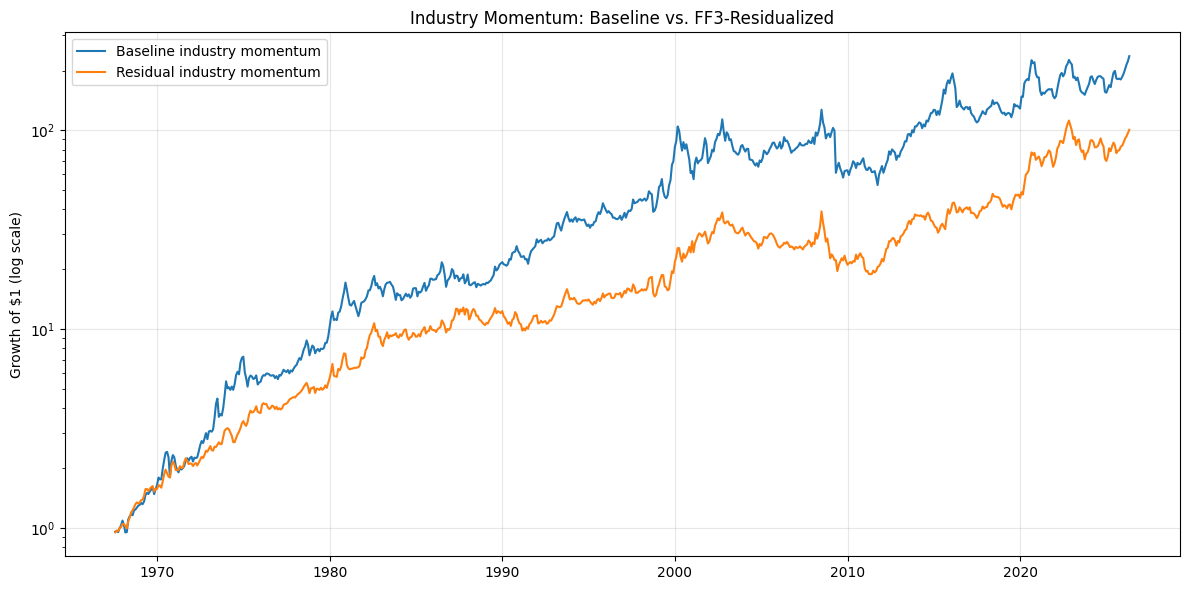

In [13]:
# compare plots
fig, ax = plt.subplots(figsize=(12, 6))

base_cum = (1 + baseline_aligned / 100).cumprod()
resid_cum = (1 + residual_aligned / 100).cumprod()

ax.plot(base_cum.index, base_cum.values, label="Baseline industry momentum", linewidth=1.5)
ax.plot(resid_cum.index, resid_cum.values, label="Residual industry momentum", linewidth=1.5)

ax.set_yscale("log")
ax.set_title("Industry Momentum: Baseline vs. FF3-Residualized")
ax.set_ylabel("Growth of $1 (log scale)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Alpha Test

In [15]:
# load ff3 factors + mom
factors = pd.read_parquet(RAW_DIR / "ff3_factors.parquet", engine="fastparquet")
print(factors.columns.tolist())
print(factors.head())
print(factors.tail())

['Mkt-RF', 'SMB', 'HML', 'RF', 'UMD']
            Mkt-RF   SMB   HML    RF   UMD
date                                      
1963-07-31   -0.39 -0.57 -0.81  0.27  1.01
1963-08-31    5.08 -0.95  1.70  0.25  1.00
1963-09-30   -1.57 -0.25  0.00  0.27  0.12
1963-10-31    2.54 -0.57 -0.04  0.29  3.13
1963-11-30   -0.86 -1.16  1.73  0.27 -0.78
            Mkt-RF   SMB   HML    RF   UMD
date                                      
2025-12-31   -0.36 -1.03  2.36  0.34 -2.33
2026-01-31    1.03  2.12  3.86  0.30  4.98
2026-02-28   -1.17  0.24  2.65  0.28  1.27
2026-03-31   -5.18  0.44  3.35  0.29  1.54
2026-04-30    9.94  0.13 -1.27  0.29  9.62


In [16]:
# make alpha test function
def run_alpha_test(strategy_returns, factors, factor_cols=None):
    if factor_cols is None:
        factor_cols = ["Mkt-RF", "SMB", "HML", "UMD"]

    common_idx = strategy_returns.index.intersection(factors.index)
    y = strategy_returns.loc[common_idx]
    X = factors.loc[common_idx, factor_cols]

    # long-short strategy returns are already excess returns, so we don't subtract RF from y
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    return model

print("Baseline Industry Momentum - Alpha Test: ")
base_model = run_alpha_test(baseline_aligned, factors)
print(base_model.summary())
print()
print("Residual Industry Momentum - Alpha Test: ")
resid_model = run_alpha_test(residual_aligned, factors)
print(resid_model.summary())

Baseline Industry Momentum - Alpha Test: 
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     119.2
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.47e-77
Time:                        23:02:44   Log-Likelihood:                -2009.1
No. Observations:                 706   AIC:                             4028.
Df Residuals:                     701   BIC:                             4051.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [17]:
def extract_results(model, label):
    return {
        "Strategy": label,
        "Alpha (monthly %)":  model.params["const"],
        "Alpha t-stat":       model.tvalues["const"],
        "Alpha (annual %)":   model.params["const"] * 12,
        "Beta Mkt-RF":        model.params["Mkt-RF"],
        "Beta SMB":           model.params["SMB"],
        "Beta HML":           model.params["HML"],
        "Beta UMD":           model.params["UMD"],
        "UMD t-stat":         model.tvalues["UMD"],
        "R-squared":          model.rsquared,
    }

results = pd.DataFrame([
    extract_results(base_model, "Baseline"),
    extract_results(resid_model, "Residual"),
]).set_index("Strategy").T

results = results.round(3)
print(results)

Strategy           Baseline  Residual
Alpha (monthly %)     0.289     0.369
Alpha t-stat          1.664     2.153
Alpha (annual %)      3.470     4.433
Beta Mkt-RF           0.110     0.061
Beta SMB             -0.084     0.034
Beta HML             -0.004     0.137
Beta UMD              1.058     0.535
UMD t-stat           18.004     9.097
R-squared             0.534     0.219


### Robustness Checks

In [22]:
# loading data
SIG_DIR = Path("../data/raw/signals")

variant_files = sorted([f for f in os.listdir(SIG_DIR) if f.endswith(".parquet")])
print(f"Found {len(variant_files)} variant files:")
for f in variant_files:
    print(f"  {f}")

summary_path = SIG_DIR / "summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    print(f"\nSummary CSV:")
    print(summary)

Found 21 variant files:
  baseline_L12.parquet
  baseline_L6.parquet
  baseline_L9.parquet
  residual_L12_W24_FF3.parquet
  residual_L12_W24_MKT.parquet
  residual_L12_W36_FF3.parquet
  residual_L12_W36_MKT.parquet
  residual_L12_W48_FF3.parquet
  residual_L12_W48_MKT.parquet
  residual_L6_W24_FF3.parquet
  residual_L6_W24_MKT.parquet
  residual_L6_W36_FF3.parquet
  residual_L6_W36_MKT.parquet
  residual_L6_W48_FF3.parquet
  residual_L6_W48_MKT.parquet
  residual_L9_W24_FF3.parquet
  residual_L9_W24_MKT.parquet
  residual_L9_W36_FF3.parquet
  residual_L9_W36_MKT.parquet
  residual_L9_W48_FF3.parquet
  residual_L9_W48_MKT.parquet

Summary CSV:
                 variant first_valid nan_pct    mean     std     p10     p90
0            baseline_L6  1964-01-31    1.1%   5.322  16.200 -13.095  23.780
1            baseline_L9  1964-04-30    1.5%   8.635  21.156 -15.810  32.571
2           baseline_L12  1964-07-31    1.9%  11.953  25.321 -17.072  40.786
3    residual_L6_W24_MKT  1965-12-31    4

In [25]:
# do the same as above for all variations of baselines/residuals
def evaluate_variant(signal_df, returns_df, factors, name):
    strat = build_strategy_returns(signal_df, returns_df)
    if len(strat) < 60:  # need at least 5 years to bother
        return None

    # annualized stats
    ann_ret = strat.mean() * 12
    ann_vol = strat.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol

    # max drawdown
    cum = (1 + strat / 100).cumprod()
    running_max = cum.cummax()
    drawdown = (cum / running_max - 1) * 100
    max_dd = drawdown.min()  # most negative value

    # worst month
    worst_month = strat.min()

    # alpha test
    model = run_alpha_test(strat, factors)

    return {
        "variant": name,
        "n_months": len(strat),
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "worst_month": worst_month,
        "alpha_monthly": model.params["const"],
        "alpha_annual": model.params["const"] * 12,
        "alpha_tstat": model.tvalues["const"],
        "beta_umd": model.params["UMD"],
        "umd_tstat": model.tvalues["UMD"],
        "r_squared": model.rsquared,
    }

all_results = []

for fname in variant_files:
    variant_name = fname.replace(".parquet", "")
    sig = pd.read_parquet(SIG_DIR / fname, engine="fastparquet")
    result = evaluate_variant(sig, industry_returns, factors, variant_name)
    if result is not None:
        all_results.append(result)
    print(f"Processed: {variant_name}")

robustness = pd.DataFrame(all_results).set_index("variant")

Processed: baseline_L12
Processed: baseline_L6
Processed: baseline_L9
Processed: residual_L12_W24_FF3
Processed: residual_L12_W24_MKT
Processed: residual_L12_W36_FF3
Processed: residual_L12_W36_MKT
Processed: residual_L12_W48_FF3
Processed: residual_L12_W48_MKT
Processed: residual_L6_W24_FF3
Processed: residual_L6_W24_MKT
Processed: residual_L6_W36_FF3
Processed: residual_L6_W36_MKT
Processed: residual_L6_W48_FF3
Processed: residual_L6_W48_MKT
Processed: residual_L9_W24_FF3
Processed: residual_L9_W24_MKT
Processed: residual_L9_W36_FF3
Processed: residual_L9_W36_MKT
Processed: residual_L9_W48_FF3
Processed: residual_L9_W48_MKT


In [26]:
# formatting results
display = robustness.copy()
for col in ["ann_return", "ann_vol", "max_dd", "worst_month", "alpha_monthly", "alpha_annual"]:
    display[col] = display[col].round(2)
for col in ["sharpe", "alpha_tstat", "beta_umd", "umd_tstat", "r_squared"]:
    display[col] = display[col].round(3)

display = display.sort_index()

print(display.to_string())

                      n_months  ann_return  ann_vol  sharpe  max_dd  worst_month  alpha_monthly  alpha_annual  alpha_tstat  beta_umd  umd_tstat  r_squared
variant                                                                                                                                                   
baseline_L12               741       10.94    20.98   0.522  -58.20       -38.69           0.22          2.68        1.314     1.056     18.340      0.530
baseline_L6                747        6.59    19.61   0.336  -54.30       -39.02          -0.01         -0.09       -0.045     0.844     14.520      0.377
baseline_L9                744        9.25    20.36   0.454  -57.30       -27.73           0.10          1.21        0.586     1.003     16.504      0.497
residual_L12_W24_FF3       718       11.40    15.32   0.744  -39.91       -15.49           0.67          8.10        4.249     0.410      7.572      0.149
residual_L12_W24_MKT       718       10.70    17.37   0.616  -53.63   

In [30]:
robustness.to_csv(Path("../results") / "robustness_table.csv")

In [33]:
# all 12-1 lookbacks for residuals have alpha |t| > 2
twelve_one_residual = robustness[robustness.index.str.startswith("residual_L12")]
twelve_one_baseline = robustness[robustness.index == "baseline_L12"]

print("12-1 BASELINE:")
print(twelve_one_baseline[["sharpe", "max_dd", "alpha_tstat", "beta_umd", "r_squared"]].to_string())
print(f"\nSharpe range: {twelve_one_residual['sharpe'].min():.2f} to {twelve_one_residual['sharpe'].max():.2f}")
print(f"Max DD range: {twelve_one_residual['max_dd'].min():.1f}% to {twelve_one_residual['max_dd'].max():.1f}%")
print(f"Alpha t-stat range: {twelve_one_residual['alpha_tstat'].min():.2f} to {twelve_one_residual['alpha_tstat'].max():.2f}")
print(f"UMD beta range: {twelve_one_residual['beta_umd'].min():.2f} to {twelve_one_residual['beta_umd'].max():.2f}")
print(f"R² range: {twelve_one_residual['r_squared'].min():.2f} to {twelve_one_residual['r_squared'].max():.2f}")
print(f"All have t > 2: {(twelve_one_residual['alpha_tstat'] > 2).all()}")

12-1 BASELINE:
                sharpe     max_dd  alpha_tstat  beta_umd  r_squared
variant                                                            
baseline_L12  0.521511 -58.198023     1.313859  1.056176   0.530413

Sharpe range: 0.57 to 0.75
Max DD range: -53.6% to -38.1%
Alpha t-stat range: 2.15 to 4.25
UMD beta range: 0.41 to 0.77
R² range: 0.15 to 0.37
All have t > 2: True


### Visualizations

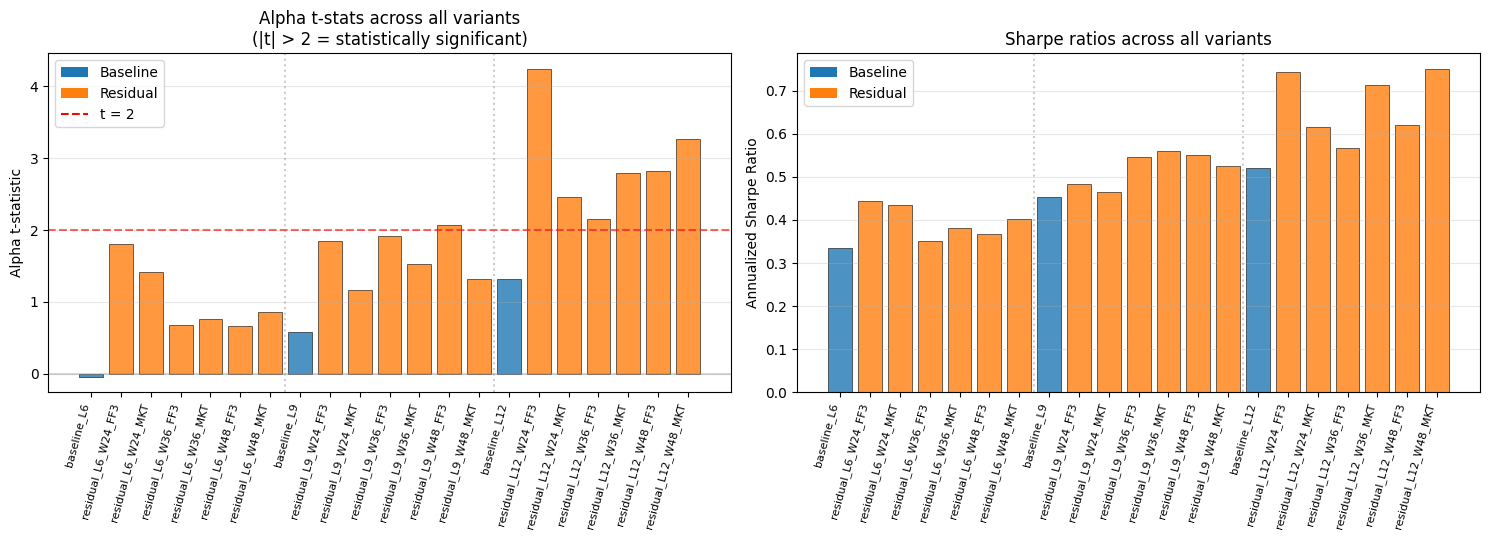

In [36]:
# robustness scatter

# Categorize variants for plotting
display = robustness.copy()
display["type"] = display.index.map(lambda x: "Baseline" if x.startswith("baseline") else "Residual")
display["lookback"] = display.index.map(
    lambda x: int(x.split("_L")[1].split("_")[0])  # extracts the L# number
)

# Sort by lookback then by variant name for cleaner visualization
display = display.sort_values(["lookback", "type"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 1: Alpha t-stats
ax = axes[0]
x_positions = range(len(display))
colors = ["#1f77b4" if t == "Baseline" else "#ff7f0e" for t in display["type"]]
bars = ax.bar(x_positions, display["alpha_tstat"], color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(display.index, rotation=75, fontsize=8, ha="right")
ax.set_ylabel("Alpha t-statistic")
ax.set_title("Alpha t-stats across all variants\n(|t| > 2 = statistically significant)")
ax.axhline(2, color="red", linestyle="--", alpha=0.6, label="t = 2 (5% significance)")
ax.axhline(0, color="gray", linestyle="-", alpha=0.3)

# Add separators between lookback groups
prev_lb = None
for i, lb in enumerate(display["lookback"].values):
    if prev_lb is not None and lb != prev_lb:
        ax.axvline(i - 0.5, color="gray", linestyle=":", alpha=0.4)
    prev_lb = lb

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#1f77b4", label="Baseline"),
    Patch(facecolor="#ff7f0e", label="Residual"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="t = 2"),
], loc="upper left")
ax.grid(True, axis="y", alpha=0.3)

# Plot 2: Sharpe ratios
ax = axes[1]
ax.bar(x_positions, display["sharpe"], color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_xticks(x_positions)
ax.set_xticklabels(display.index, rotation=75, fontsize=8, ha="right")
ax.set_ylabel("Annualized Sharpe Ratio")
ax.set_title("Sharpe ratios across all variants")

prev_lb = None
for i, lb in enumerate(display["lookback"].values):
    if prev_lb is not None and lb != prev_lb:
        ax.axvline(i - 0.5, color="gray", linestyle=":", alpha=0.4)
    prev_lb = lb

ax.legend(handles=[
    Patch(facecolor="#1f77b4", label="Baseline"),
    Patch(facecolor="#ff7f0e", label="Residual"),
], loc="upper left")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/robustness_bars.png", dpi=150, bbox_inches="tight")
plt.show()

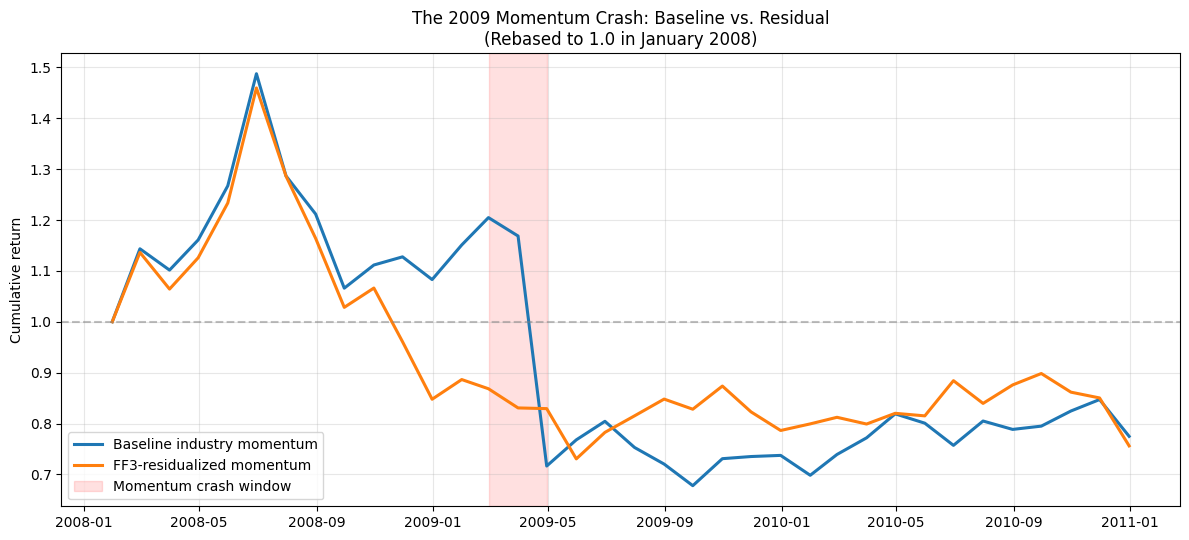

In [37]:
# 2009 crash

crash_window = slice("2008-01", "2010-12")

base_window = (1 + baseline_aligned.loc[crash_window] / 100).cumprod()
resid_window = (1 + residual_aligned.loc[crash_window] / 100).cumprod()

base_window = base_window / base_window.iloc[0]
resid_window = resid_window / resid_window.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(base_window.index, base_window.values, label="Baseline industry momentum", 
        linewidth=2.2, color="#1f77b4")
ax.plot(resid_window.index, resid_window.values, label="FF3-residualized momentum", 
        linewidth=2.2, color="#ff7f0e")

# Highlight the March-April 2009 crash window
ax.axvspan(pd.Timestamp("2009-03-01"), pd.Timestamp("2009-04-30"), 
           color="red", alpha=0.12, label="Momentum crash window")

ax.set_title("The 2009 Momentum Crash: Baseline vs. Residual\n"
             "(Rebased to 1.0 in January 2008)", fontsize=12)
ax.set_ylabel("Cumulative return")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/crash_2009.png", dpi=150, bbox_inches="tight")
plt.show()

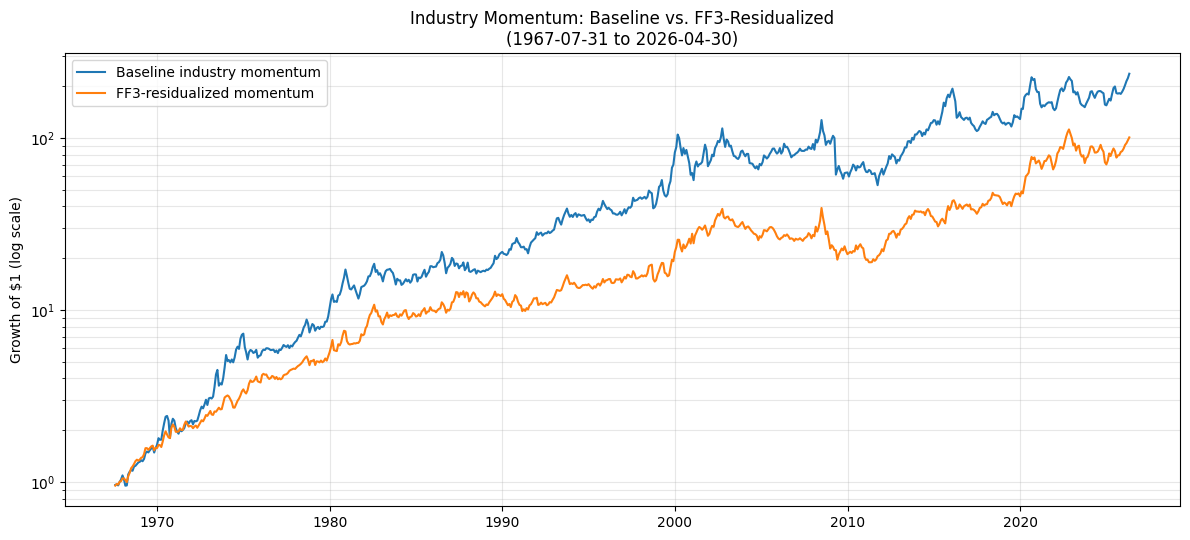

In [38]:
# full cumulative curve

fig, ax = plt.subplots(figsize=(12, 5.5))

base_cum = (1 + baseline_aligned / 100).cumprod()
resid_cum = (1 + residual_aligned / 100).cumprod()

ax.plot(base_cum.index, base_cum.values, label="Baseline industry momentum", 
        linewidth=1.5, color="#1f77b4")
ax.plot(resid_cum.index, resid_cum.values, label="FF3-residualized momentum", 
        linewidth=1.5, color="#ff7f0e")

ax.set_yscale("log")
ax.set_title("Industry Momentum: Baseline vs. FF3-Residualized\n"
             f"({common_start.date()} to {common_end.date()})", fontsize=12)
ax.set_ylabel("Growth of $1 (log scale)")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../results/figures/cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()

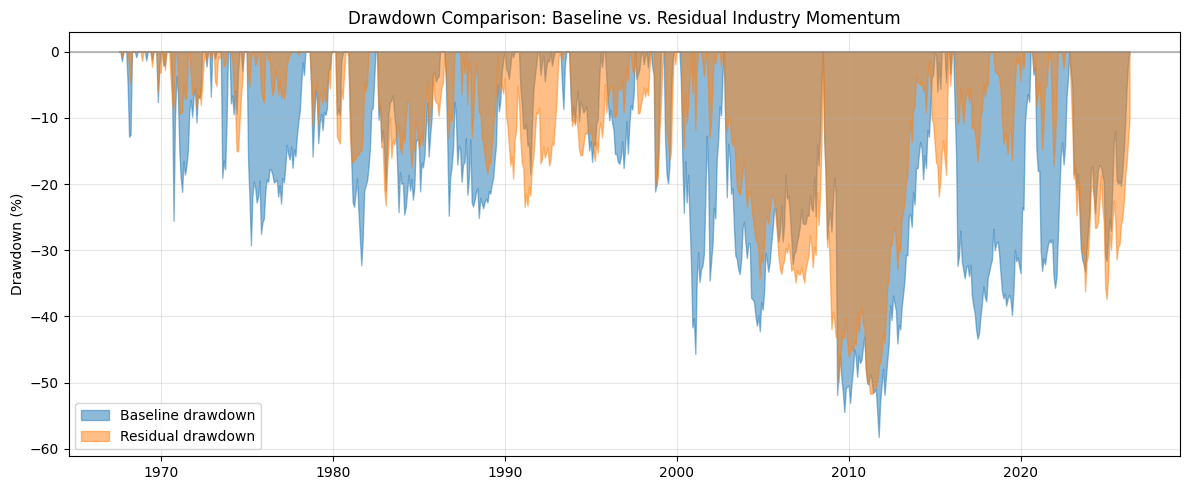

Baseline max drawdown: -58.2%
Residual max drawdown: -51.7%


In [39]:
# drawdown comparison

def compute_drawdown(returns_pct):
    cum = (1 + returns_pct / 100).cumprod()
    running_max = cum.cummax()
    return (cum / running_max - 1) * 100

base_dd = compute_drawdown(baseline_aligned)
resid_dd = compute_drawdown(residual_aligned)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(base_dd.index, base_dd.values, 0, 
                color="#1f77b4", alpha=0.5, label="Baseline drawdown")
ax.fill_between(resid_dd.index, resid_dd.values, 0, 
                color="#ff7f0e", alpha=0.5, label="Residual drawdown")

ax.set_title("Drawdown Comparison: Baseline vs. Residual Industry Momentum", fontsize=12)
ax.set_ylabel("Drawdown (%)")
ax.axhline(0, color="gray", linestyle="-", alpha=0.5)
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"Baseline max drawdown: {base_dd.min():.1f}%")
print(f"Residual max drawdown: {resid_dd.min():.1f}%")

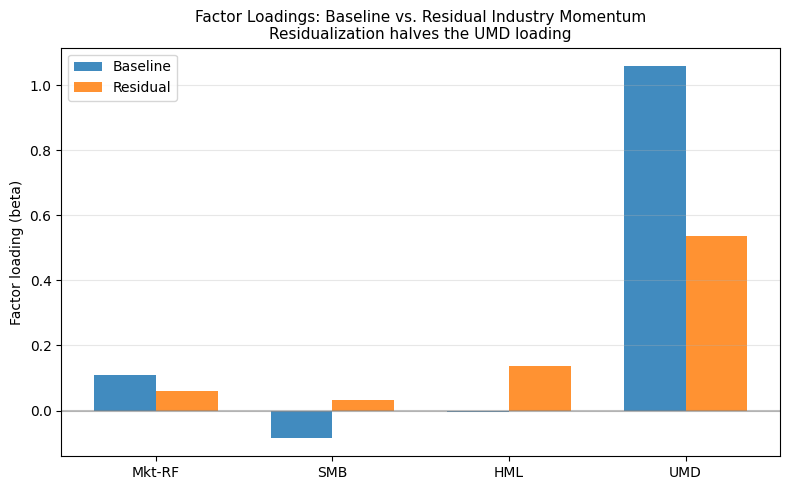

In [41]:
# factor loadings

loadings = pd.DataFrame({
    "Baseline": base_model.params[["Mkt-RF", "SMB", "HML", "UMD"]],
    "Residual": resid_model.params[["Mkt-RF", "SMB", "HML", "UMD"]],
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(loadings))
width = 0.35

ax.bar(x - width/2, loadings["Baseline"], width, label="Baseline", color="#1f77b4", alpha=0.85)
ax.bar(x + width/2, loadings["Residual"], width, label="Residual", color="#ff7f0e", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(loadings.index)
ax.set_ylabel("Factor loading (beta)")
ax.set_title("Factor Loadings: Baseline vs. Residual Industry Momentum\n"
             "Residualization halves the UMD loading", fontsize=11)
ax.axhline(0, color="gray", linestyle="-", alpha=0.5)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../results/figures/factor_loadings.png", dpi=150, bbox_inches="tight")
plt.show()